In [8]:
!pip install -U langchain-mistralai

In [7]:
import sys
sys.path.append("../ingestion/python/src")
sys.path.append("../ingestion/python/enrichment_agent")

from utils import *
from langgraph.graph import StateGraph, START, END
from IPython.display import Image, display

from silver_enrichment import *
from graph_silver_enrichment import *
from APIendpoint import PlacesAPI
from database import Database

import os
from dotenv import load_dotenv
load_dotenv(override=True)

llm = LLM()
places_api = PlacesAPI(os.getenv('MAPS_APP_KEY'))
db = Database()

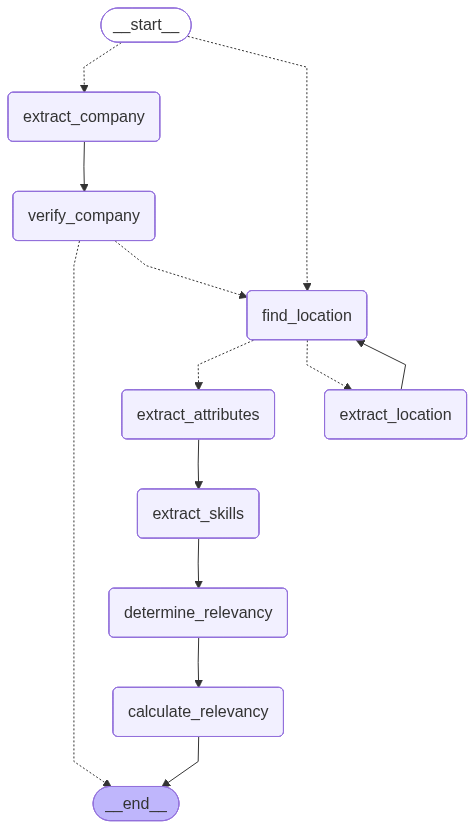

In [10]:

graph = builder.compile()
display(Image(graph.get_graph().draw_mermaid_png()))

In [11]:
# raw = db.execute("SELECT * FROM raw.job_offer WHERE company = '' LIMIT 1;")
query = ("SELECT DISTINCT ON (id_job) * "
        "FROM raw.job_offer "
        "ORDER BY id_job "
        "LIMIT 1;")
query = ("SELECT DISTINCT ON (id_job) * "
        "FROM raw.job_offer "
        "WHERE id_job = 'cj_3ec22096b09de31a73c7f830f5c1c3f4' ;")



query_prompt = ("SELECT id_prompt, prompt "
        "FROM analytics.prompt_relevancy "
        "LIMIT 1;")


raw = db.execute(query)
prompt = db.execute(query_prompt)
states = []
for row in raw:
    states.append(map_bronze_to_JobOfferState(row) | map_prompt_to_JobOfferState(prompt[0]))

In [12]:


results = []
for state in states:
    r = graph.invoke(state)
    row = (r.get('id_job'), r)
    results.append(row)

⚠️  find_location: aucun résultat pour Blend360 @ Montevideo
⚠️  find_location: aucun résultat pour Blend360 @ Montevideo, UY


In [13]:
import json
import datetime
from LLMprovider import LLM

llm = LLM()
name = llm.enrichement.model

# Fusion directe de la liste de tuples en un dictionnaire unique
dico_unique = dict(results)

# On convertit tout ce qui est datetime en chaîne de caractères (ISO) avant l'enregistrement
dico_serialisable = json.loads(json.dumps(dico_unique, default=str))

nom_fichier = datetime.datetime.now().strftime("%Y-%m-%d_%H-%M-%S") + name
write_json('./test_graph', nom_fichier, dico_serialisable)

results

[('cj_3ec22096b09de31a73c7f830f5c1c3f4',
  {'id_job': 'cj_3ec22096b09de31a73c7f830f5c1c3f4',
   'id_company': None,
   'id_location': None,
   'api_source': 'careerjet',
   'job_title': 'Fullstack AI Engineer',
   'offer_description': ' clients through the power of <b>data</b> science, AI, technology, and people. With a mission to fuel bold visions, Blend tackles... value and fostering innovation for its clients by harnessing world-class people and <b>data</b>-driven strategy. We believe',
   'contract_type': 'fulltime',
   'is_remote': False,
   'job_publisher': None,
   'location_raw': 'Montevideo, UY',
   'offer_url': 'https://jobviewtrack.com/v2/U6opK8i5qrArknDwdyM29Y510UX5DWcSceyCco0AU7YDmZNJExePViGVj7B8tiHTyhcvaUeP9wuanZQqNwxy3ZpxsTxqfWvFcwR9t4iZtAbyzC-GZm4dp48UM0QYwhuJF4W4xxeqYx4bgaPqJV9dy4M0k0M0E2Mk1JDO9ceAaZjeiL-mM1ZRDb1wtJmYnnlHlq1PWdGaj3M33-ZmDxeLGu8JaLRO58-CLBdBREQA1cM',
   'source_platform': None,
   'published_at': datetime.datetime(2026, 6, 23, 22, 21, 30, tzinfo=datetim

In [14]:
from LLMprovider import LLM

llm = LLM()

name = llm.enrichement
print(name.model)

ministral-8b-2512


In [8]:
bronze = ("SELECT * "
        "FROM raw.job_offer "
        "WHERE job_title = 'Senior Ml Engineer - Python & Ml Deployments' ;")


gold = ("SELECT  * "
        "FROM serving.job_offer "
        "WHERE job_title = 'Senior Ml Engineer - Python & Ml Deployments' ;")



b = db.execute(bronze)
r = db.execute(gold)

print("BRONZE")
print(b)
print("\nGOLD")
print(r)

BRONZE
[{'id_job': 'cj_f429135c90f3661bfda9328fcd657c07', 'api_source': 'careerjet', 'job_title': 'Senior Ml Engineer - Python & Ml Deployments', 'contract_type': None, 'job_publisher': None, 'company': 'Visa Hunt', 'company_website': None, 'location_raw': 'Tandil, Provincia de Buenos Aires - Buenos Aires', 'city': 'Tandil, Provincia de Buenos Aires - Buenos Aires', 'country': 'AR', 'latitude': None, 'longitude': None, 'is_remote': None, 'offer_url': 'https://jobviewtrack.com/v2/pVHK12nNBt_zLyI98wSfpaR6csfcN9SpomJ26NG2E8lI_tj8N-zaAVSFe3U846PDEhMKFTQOWIcqGk4qqKAsVo19FsPxPpnRZaGiyHe-Yz5R79pl3L5RA-_FK0IenidNzDS1BgC4Smdem7WZ7LgQZOvSmyckrvfKg-gkTA1WAxftsQFlwcY5hYfNneXQ5xIicjQs9CUm9Pp-ULh0mRMCQSAMdcfKLrnfWtA9lDXcOuI', 'is_direct': None, 'source_platform': None, 'offer_description': 'Zarego is seeking a Machine Learning <b>Engineer</b> to join our team.  You will build intelligent systems, work with <b>data</b>', 'job_highlights': None, 'salary_raw': None, 'salary_min': None, 'salary_max': No

In [14]:
from datetime import datetime

def clean_data(obj):
    """Convertit récursivement les datetime en chaînes de caractères ISO."""
    if isinstance(obj, dict):
        return {k: clean_data(v) for k, v in obj.items()}
    elif isinstance(obj, list):
        return [clean_data(item) for item in obj]
    elif isinstance(obj, datetime):
        return obj.isoformat()
    return obj

# 1. Fusionner le dictionnaire b[0] avec r[0]
dict_0 = b[0] | r[0]

# 2. Fusionner le dictionnaire b[1] avec r[1]
dict_1 = b[1] | r[1]

# 3. Rassembler le tout dans une structure globale propre (ex: une liste fusionnée)
merged_data = [clean_data(dict_0), clean_data(dict_1)]

# 4. Écrire le résultat final dans votre fichier JSON
write_json('./test_graph', "Inco", merged_data)


In [17]:
from rapidfuzz import fuzz
fuzz.WRatio("Contratación directo por cliente", "Direccion Regional Metropolitana")

43.75